In [1]:
import pandas as pd 
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv("./fraudTrain.csv", index_col=0)




In [3]:
data.head()


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
data.drop(columns=["first","last"] , inplace=True)

data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
data.nunique()


trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
dtype: int64

In [6]:
data.drop(columns=["trans_num","unix_time","merch_lat","merch_long"] , inplace=True)

In [7]:
data.columns


Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop',
       'job', 'dob', 'is_fraud'],
      dtype='str')

In [8]:
data.dtypes

trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
is_fraud                   int64
dtype: object

In [9]:

fraud = data[data['is_fraud'] == 1]
non_fraud = data[data['is_fraud'] == 0]

# 2. Randomly sample non-fraud to match the number of fraud cases (50/50 ratio)
# You can also use 'n=len(fraud) * 10' for a 10/90 ratio
non_fraud_downsampled = non_fraud.sample(n=len(fraud), random_state=42)

# 3. Combine back into a small, balanced plotting dataframe
plot_df = pd.concat([fraud, non_fraud_downsampled]).sample(frac=1) 

data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,0


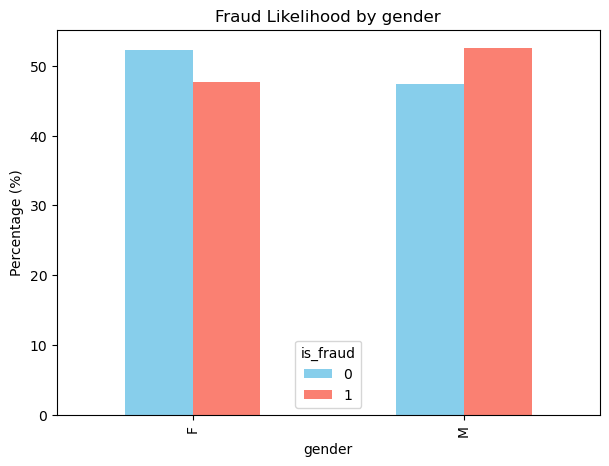

In [10]:


def plot_bar(df , col , width=7):
    counts = pd.crosstab(df[col], df['is_fraud'])
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    percentages.plot.bar(stacked=False, color=['skyblue', 'salmon'],figsize=(width,5))
    plt.ylabel('Percentage (%)')
    plt.title(f'Fraud Likelihood by {col}')
    plt.show()
  

def sample_and_plot(df , col , width=7 , nsamples=100):
    top_fraud_col = df[col].value_counts().nlargest(nsamples).index
    filtered_df = df[plot_df[col].isin(top_fraud_col)]
    plot_bar(filtered_df,col,width)

plot_bar(plot_df ,"gender")

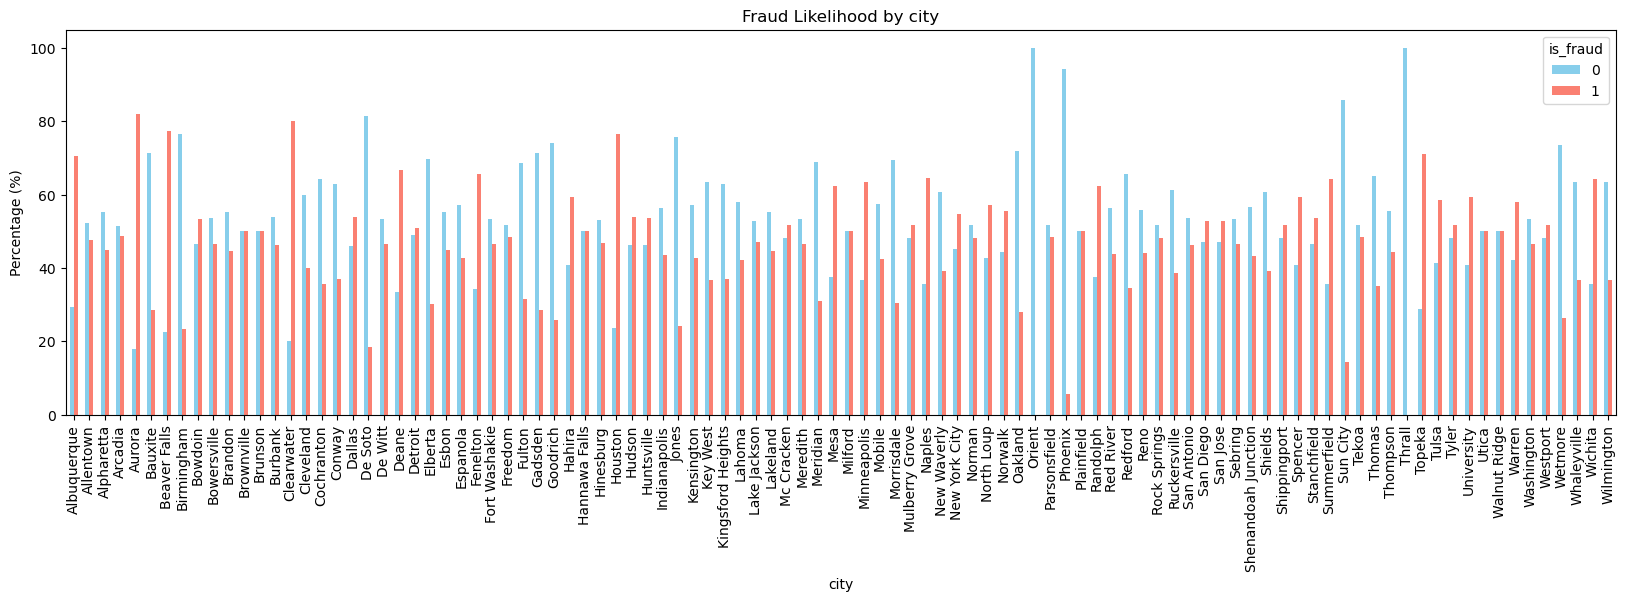

In [11]:

sample_and_plot(plot_df ,'city',20,100)

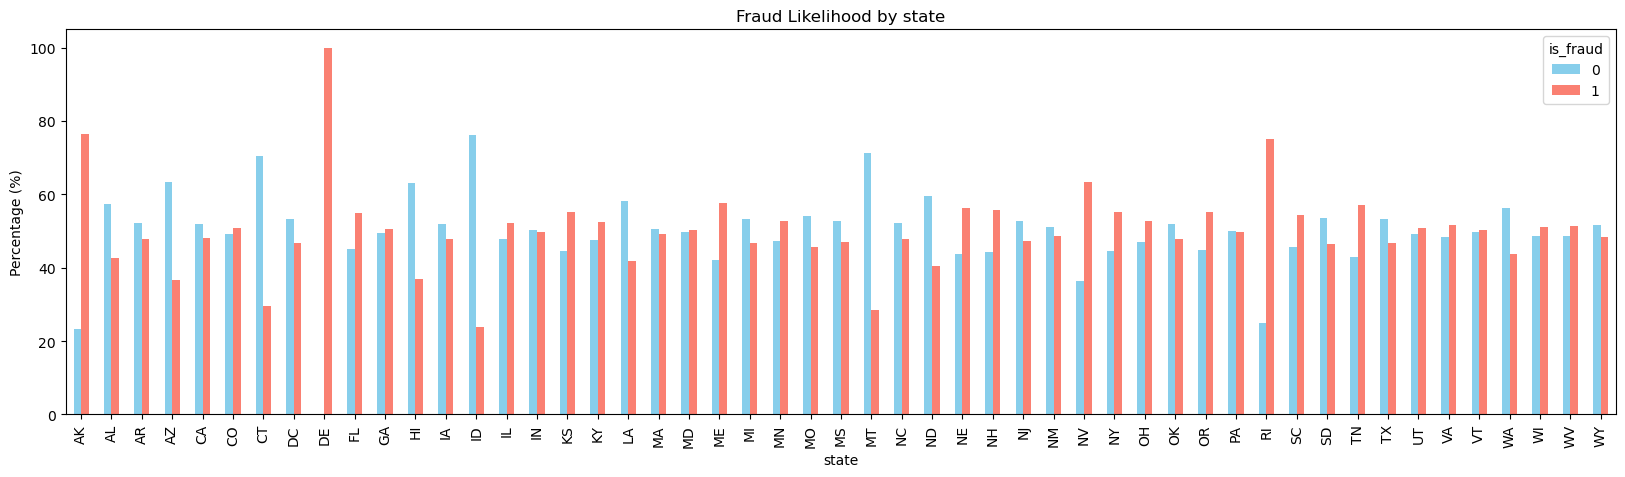

In [12]:

sample_and_plot(plot_df ,'state',20,100)

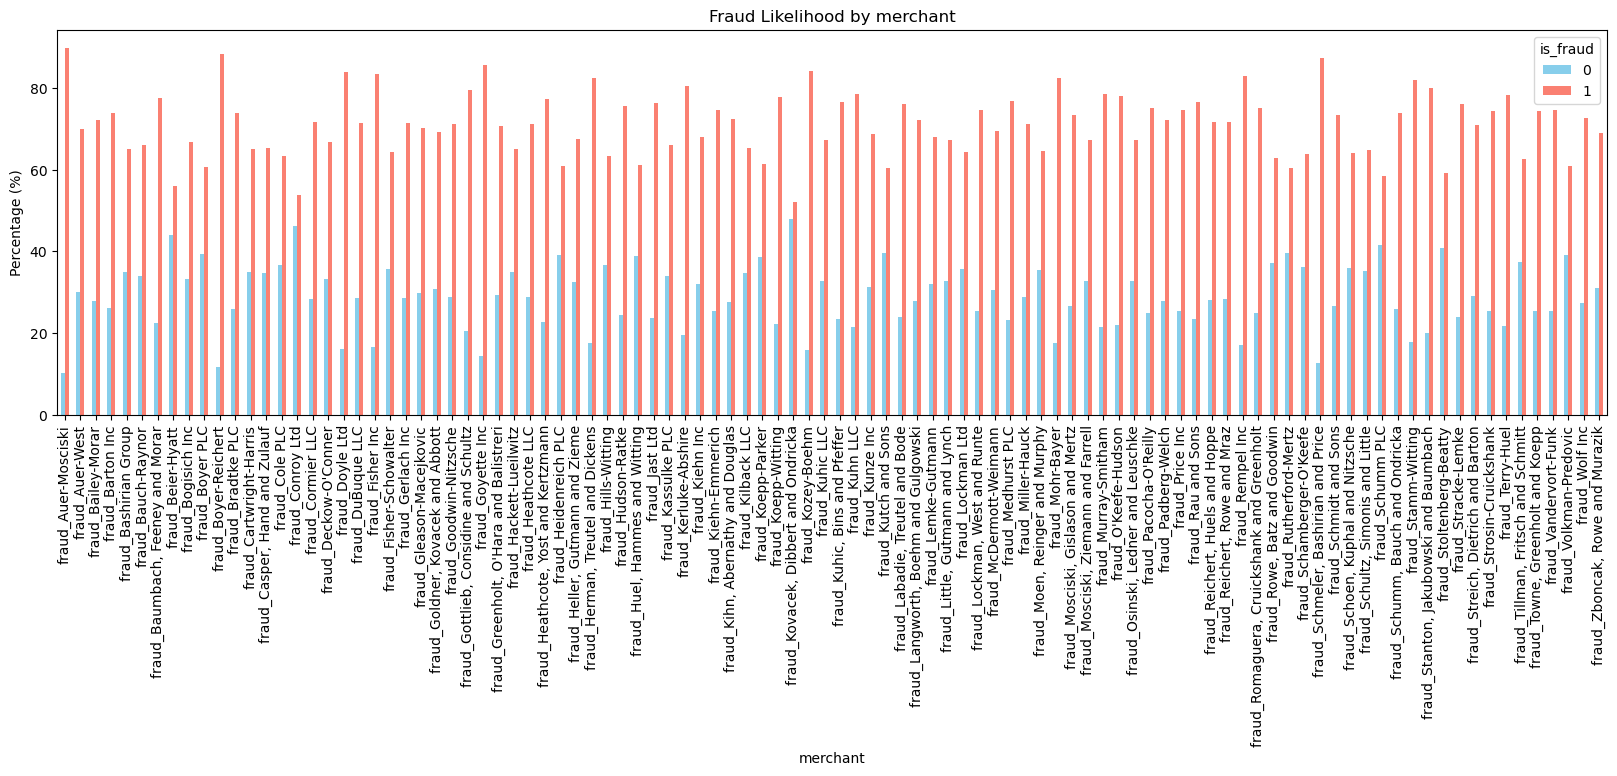

In [13]:

sample_and_plot(plot_df ,'merchant',20,100)

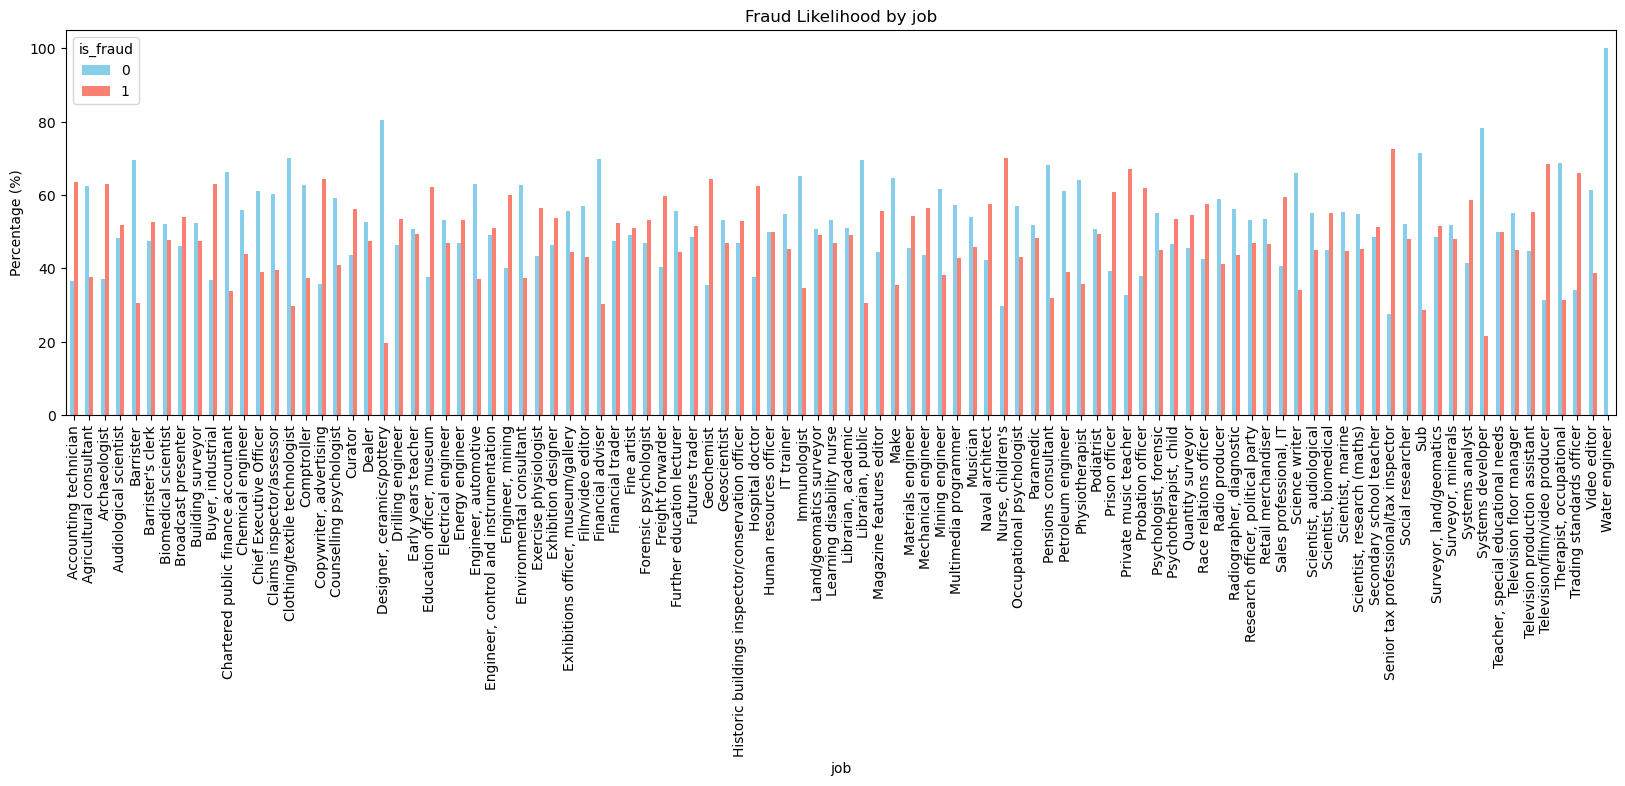

In [14]:

sample_and_plot(plot_df ,'job',20,100)

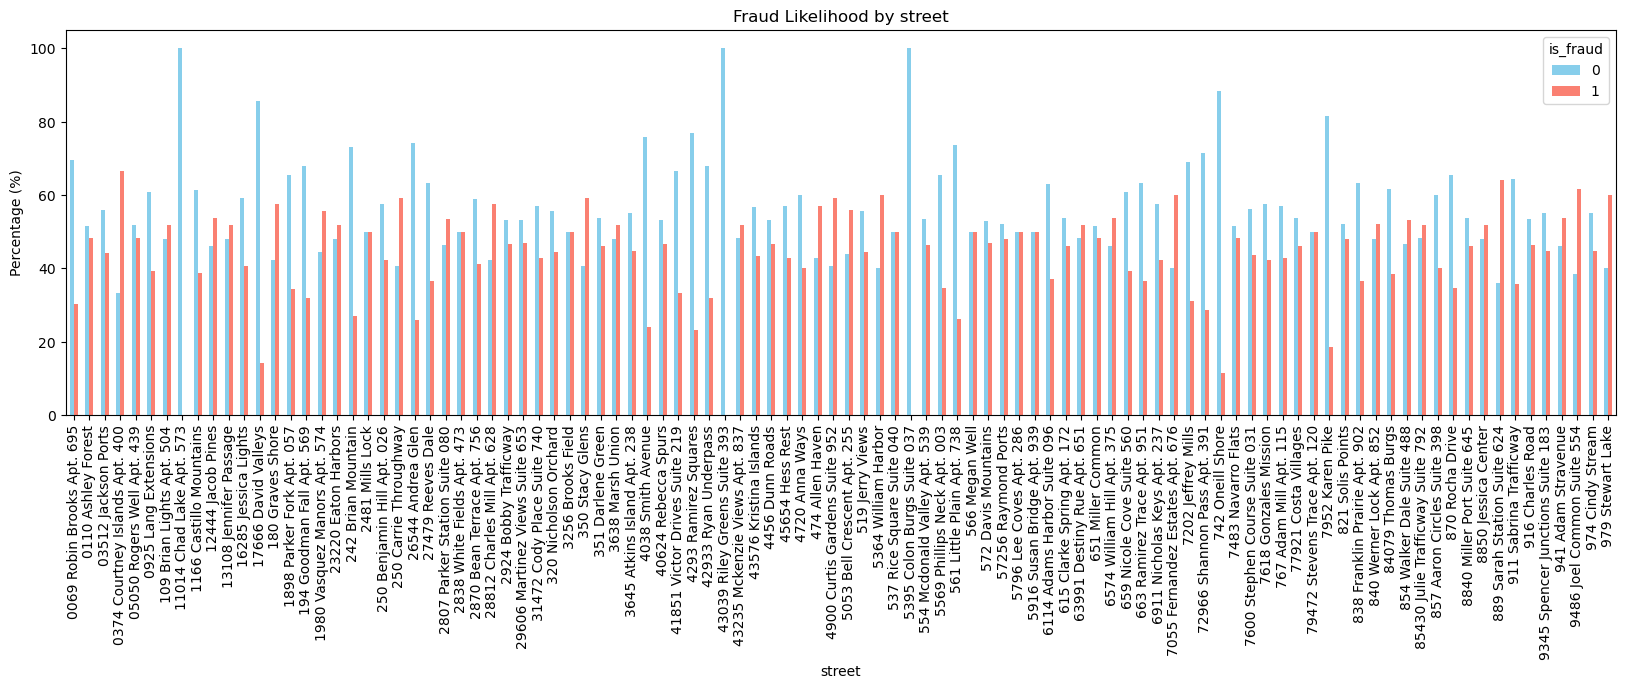

In [15]:
sample_and_plot(plot_df ,'street',20,100)

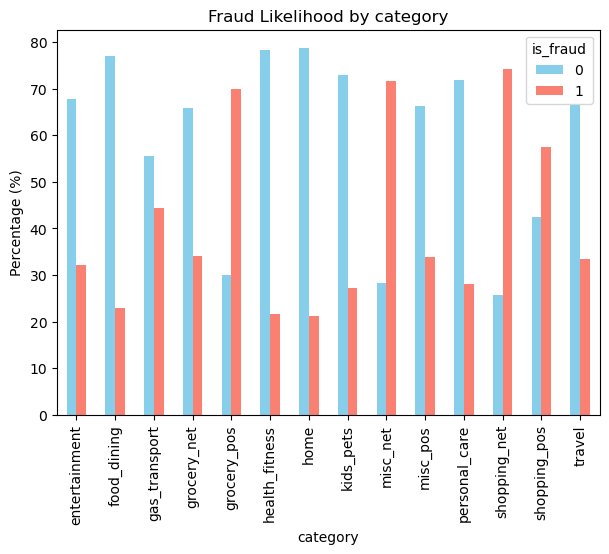

In [16]:
plot_bar(plot_df,"category")

In [17]:
from datetime import date

plot_df['dob'] = pd.to_datetime(plot_df['dob'])
today = pd.to_datetime(date.today())
plot_df['age'] = (today - plot_df['dob']).dt.days // 365
plot_df["age"]

478965     70
288002     32
373690     97
110202     79
1188141    42
           ..
625961     32
215465     33
622506     62
564362     52
16893      50
Name: age, Length: 15012, dtype: int64

<Axes: >

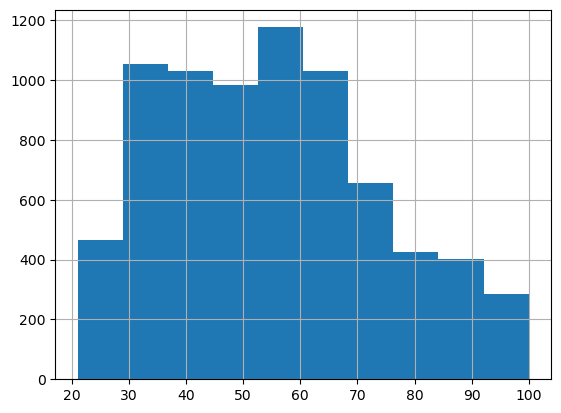

In [18]:
plot_df[plot_df["is_fraud"]==1]["age"].hist()

<Axes: >

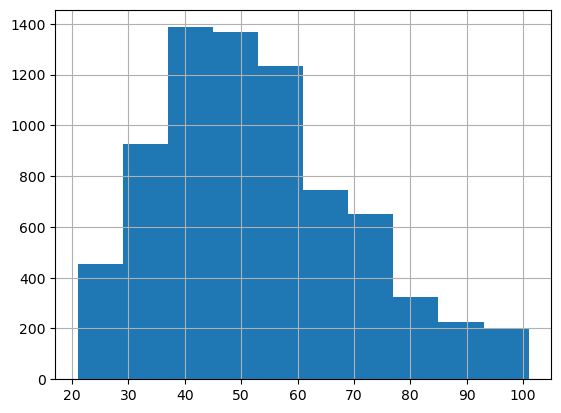

In [19]:
plot_df[plot_df["is_fraud"]==0]["age"].hist()

In [20]:
date_time = pd.to_datetime(plot_df['trans_date_trans_time'], format='%Y-%m-%d %H:%M:%S')

plot_df['day_of_week'] = date_time.dt.day_of_week
plot_df['day_of_month'] = date_time.dt.day
plot_df['time_of_day'] = date_time.dt.hour
plot_df['month'] = date_time.dt.month

plot_df

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,long,city_pop,job,dob,is_fraud,age,day_of_week,day_of_month,time_of_day,month
478965,2019-07-29 01:33:22,4254074738931278,"fraud_Streich, Hansen and Veum",gas_transport,24.03,M,69085 Short Shores,Allentown,NY,14707,...,-78.0594,239,Radio producer,1956-05-02,1,70,0,29,1,7
288002,2019-05-21 15:51:52,213178765398315,fraud_Pouros-Haag,shopping_pos,6.41,M,748 Bryan Fields Suite 935,Riverton,WY,82501,...,-108.2024,19408,"Lecturer, higher education",1993-09-11,0,32,1,21,15,5
373690,2019-06-22 04:20:23,3519607465576254,"fraud_Stroman, Hudson and Erdman",gas_transport,53.75,F,34180 Lopez Plaza,Fields Landing,CA,95537,...,-124.2174,276,"Scientist, audiological",1929-05-06,0,97,5,22,4,6
110202,2019-03-04 02:10:33,2657850734909997,"fraud_Casper, Hand and Zulauf",grocery_pos,311.46,M,04139 Johnson Prairie Suite 401,Detroit,MI,48206,...,-83.1087,673342,Trading standards officer,1946-11-01,1,79,0,4,2,3
1188141,2020-05-11 13:10:40,370877495212014,fraud_Pfeffer and Sons,shopping_pos,114.47,F,25961 Beverly Union Apt. 042,North Wilkesboro,NC,28659,...,-81.1286,21134,Dispensing optician,1984-03-06,0,42,0,11,13,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625961,2019-09-23 02:51:19,3595192916105588,fraud_Berge LLC,gas_transport,59.55,M,3283 James Station,Fayetteville,NC,28314,...,-79.0080,238602,"Scientist, research (maths)",1993-05-14,0,32,0,23,2,9
215465,2019-04-20 06:01:44,4497451418073897078,fraud_Kuhn LLC,shopping_pos,772.91,F,246 Stewart Green Suite 149,West Monroe,LA,71291,...,-92.1760,54185,"Radiographer, diagnostic",1992-11-20,1,33,5,20,6,4
622506,2019-09-22 00:45:56,3565943051129759,fraud_Hackett-Lueilwitz,grocery_pos,298.23,M,838 Dan Haven Suite 003,Webster City,IA,50595,...,-93.8262,9165,Medical secretary,1963-05-23,1,62,6,22,0,9
564362,2019-08-28 10:00:29,6011381817520024,fraud_Torp-Labadie,gas_transport,59.45,F,8619 Lisa Manors Apt. 871,Lagrange,WY,82221,...,-104.1974,635,Product/process development scientist,1973-07-13,0,52,2,28,10,8


In [21]:
#plot_df.drop(columns=['trans_date_trans_time'],inplace=True)

In [22]:
plot_df

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,long,city_pop,job,dob,is_fraud,age,day_of_week,day_of_month,time_of_day,month
478965,2019-07-29 01:33:22,4254074738931278,"fraud_Streich, Hansen and Veum",gas_transport,24.03,M,69085 Short Shores,Allentown,NY,14707,...,-78.0594,239,Radio producer,1956-05-02,1,70,0,29,1,7
288002,2019-05-21 15:51:52,213178765398315,fraud_Pouros-Haag,shopping_pos,6.41,M,748 Bryan Fields Suite 935,Riverton,WY,82501,...,-108.2024,19408,"Lecturer, higher education",1993-09-11,0,32,1,21,15,5
373690,2019-06-22 04:20:23,3519607465576254,"fraud_Stroman, Hudson and Erdman",gas_transport,53.75,F,34180 Lopez Plaza,Fields Landing,CA,95537,...,-124.2174,276,"Scientist, audiological",1929-05-06,0,97,5,22,4,6
110202,2019-03-04 02:10:33,2657850734909997,"fraud_Casper, Hand and Zulauf",grocery_pos,311.46,M,04139 Johnson Prairie Suite 401,Detroit,MI,48206,...,-83.1087,673342,Trading standards officer,1946-11-01,1,79,0,4,2,3
1188141,2020-05-11 13:10:40,370877495212014,fraud_Pfeffer and Sons,shopping_pos,114.47,F,25961 Beverly Union Apt. 042,North Wilkesboro,NC,28659,...,-81.1286,21134,Dispensing optician,1984-03-06,0,42,0,11,13,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625961,2019-09-23 02:51:19,3595192916105588,fraud_Berge LLC,gas_transport,59.55,M,3283 James Station,Fayetteville,NC,28314,...,-79.0080,238602,"Scientist, research (maths)",1993-05-14,0,32,0,23,2,9
215465,2019-04-20 06:01:44,4497451418073897078,fraud_Kuhn LLC,shopping_pos,772.91,F,246 Stewart Green Suite 149,West Monroe,LA,71291,...,-92.1760,54185,"Radiographer, diagnostic",1992-11-20,1,33,5,20,6,4
622506,2019-09-22 00:45:56,3565943051129759,fraud_Hackett-Lueilwitz,grocery_pos,298.23,M,838 Dan Haven Suite 003,Webster City,IA,50595,...,-93.8262,9165,Medical secretary,1963-05-23,1,62,6,22,0,9
564362,2019-08-28 10:00:29,6011381817520024,fraud_Torp-Labadie,gas_transport,59.45,F,8619 Lisa Manors Apt. 871,Lagrange,WY,82221,...,-104.1974,635,Product/process development scientist,1973-07-13,0,52,2,28,10,8


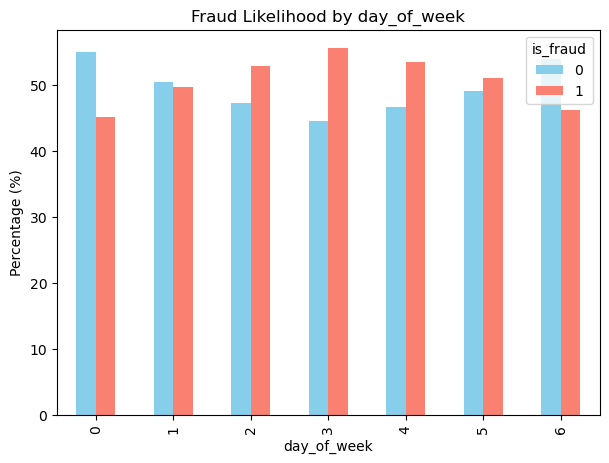

In [23]:
plot_bar(plot_df,"day_of_week")

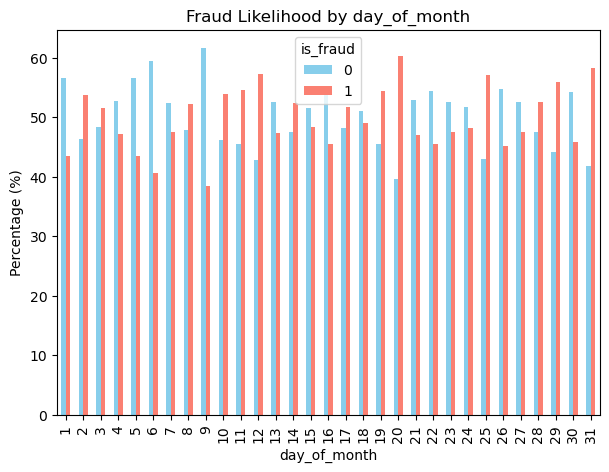

In [24]:
plot_bar(plot_df,"day_of_month")

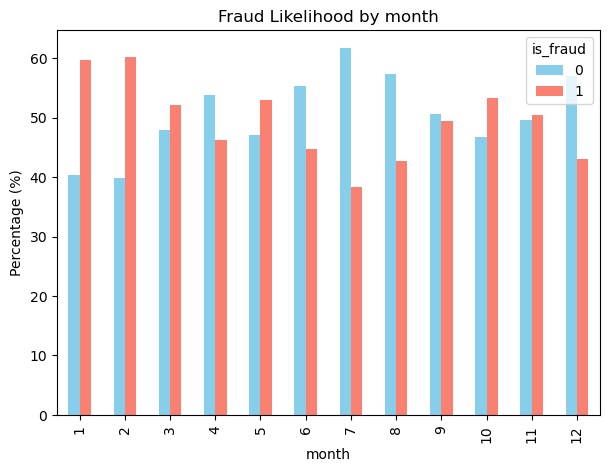

In [25]:
plot_bar(plot_df,"month")

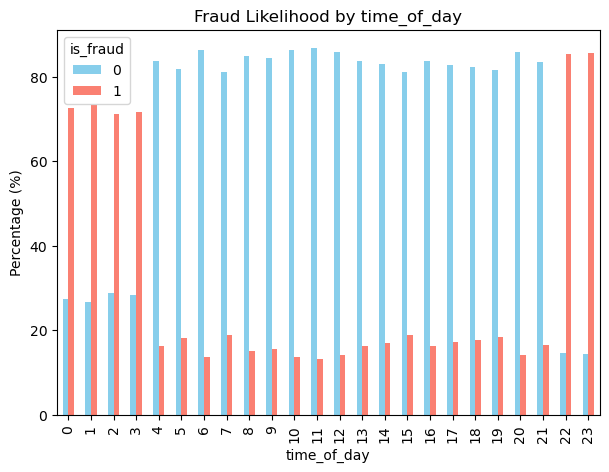

In [26]:
plot_bar(plot_df,"time_of_day")

array([[<Axes: title={'center': 'cc_num'}>,
        <Axes: title={'center': 'amt'}>],
       [<Axes: title={'center': 'zip'}>, <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'city_pop'}>]], dtype=object)

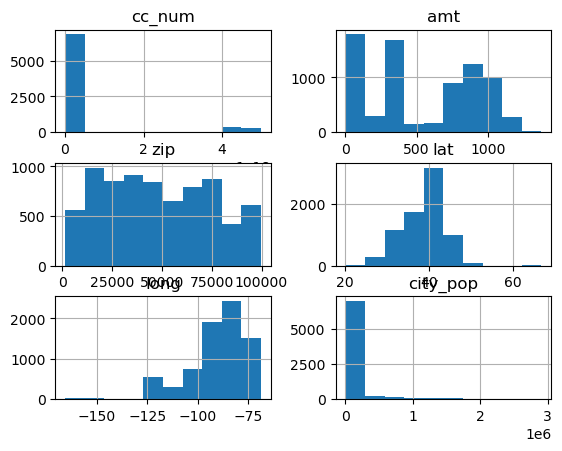

In [27]:
plot_df[plot_df["is_fraud"]==1][['cc_num','amt','zip','lat',"long" ,"city_pop"]].hist()


array([[<Axes: title={'center': 'cc_num'}>,
        <Axes: title={'center': 'amt'}>],
       [<Axes: title={'center': 'zip'}>, <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'city_pop'}>]], dtype=object)

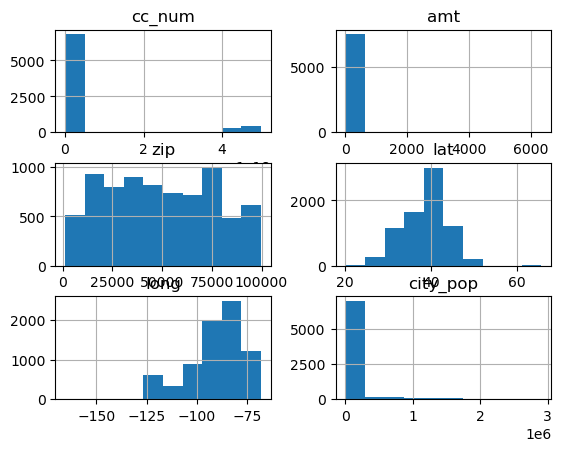

In [28]:
plot_df[plot_df["is_fraud"]==0][['cc_num','amt','zip','lat',"long" ,"city_pop"]].hist()


In [29]:
#plot_df.drop(columns=["cc_num","lat","long","city_pop","zip"] , inplace=True)

In [30]:
plot_df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop',
       'job', 'dob', 'is_fraud', 'age', 'day_of_week', 'day_of_month',
       'time_of_day', 'month'],
      dtype='str')

In [31]:
data["city"].value_counts()


city
Birmingham     5617
San Antonio    5130
Utica          5105
Phoenix        5075
Meridian       5060
               ... 
Claypool          7
Norfolk           7
Karns City        7
Bruce             7
Streator          7
Name: count, Length: 894, dtype: int64

In [37]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import make_classification

X = data.drop(columns=["is_fraud"],except="numeric")
y = data["is_fraud"]
# X = your features, y = your target
# discrete_features=True tells the model all inputs are categorical
importances = mutual_info_classif(X, y, discrete_features=True)

SyntaxError: invalid syntax (3613512634.py, line 4)

In [34]:
importances

array([3.53437088e-02, 5.50294178e-03, 2.36655486e-03, 2.15391084e-03,
       2.62709048e-02, 2.90611464e-05, 5.50294178e-03, 4.66281138e-03,
       1.51295820e-04, 5.37769636e-03, 5.37769251e-03, 5.37503250e-03,
       4.58871783e-03, 2.17251130e-03, 5.39322686e-03])